In [13]:
import numpy as np
import pandas as pd
import folium as fl
import plotly.express as px
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import hdbscan
from folium import plugins

## Optimisation de HDBSCAN

In [4]:
read_data = pd.read_csv("./flickr_data2.csv")
read_data.drop_duplicates()
read_data.head()

/var/folders/c9/twn1wmwj03x9wl7kg5psv58r0000gn/T/ipykernel_34701/58792569.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  read_data = pd.read_csv("./flickr_data2.csv")


,id,user,lat,long,tags,title,date_taken_minute,date_taken_hour,date_taken_day,date_taken_month,date_taken_year,date_upload_minute,date_upload_hour,date_upload_day,date_upload_month,date_upload_year,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,4395181099,30624617@N03,45.754858,4.821710,"chair,lyon,rhône,chaise,rhônealpes",Chaises avec vue,11.0,15,28,2,2010,23,20,28.0,2,2010.0,NaN,NaN,NaN
1,4394748717,35853470@N00,45.753270,4.862953,NaN,NaN,51.0,17,28,2,2010,52,17,28.0,2,2010.0,NaN,NaN,NaN
2,4394694699,11817998@N05,45.760655,4.846564,"365,iphone",59/365 - R46 V103 B163,29.0,17,28,2,2010,33,17,28.0,2,2010.0,NaN,NaN,NaN
3,4394803790,11545749@N06,45.784000,4.874072,"nin,nineinchnails,gift,screening,toiou,avott",2010-01-29 Toiou Avott Lyon,15.0,20,28,1,2010,38,12,28.0,2,2010.0,NaN,NaN,NaN
4,4394803554,11545749@N06,45.784000,4.874072,"lyon,nin,nineinchnails,gift,screening,toiou,avott",2010-01-28 Toiou Avott Lyon,10.0,20,28,1,2010,38,12,28.0,2,2010.0,NaN,NaN,NaN


In [5]:
wrong_data = read_data.dropna(how="all", subset=read_data.columns[[16, 18]])
fix_data = read_data.drop(index=wrong_data.index, axis=1)

toDropColumns = read_data.columns[[16, 17, 18]]
fix_data = fix_data.drop(toDropColumns, axis=1)

fix_data.drop_duplicates(inplace=True, subset=fix_data.columns.drop(["id", " tags"]), keep='last')
fix_data.drop_duplicates(inplace=True, subset=fix_data.columns.drop(["id", " title"]))


In [6]:
data2D = fix_data[[' lat', ' long']]
data2D.head()

,lat,long
9420,45.767811,4.836215
9421,45.767811,4.836215
9422,45.760649,4.846391
9423,45.760846,4.827150
9424,45.761924,4.826399


## Appliquer DBSCAN avec les bons paramètres

In [7]:
coords_rad = np.radians(data2D)
coords_rad.head()

,lat,long
9420,0.798799,0.084408
9421,0.798799,0.084408
9422,0.798674,0.084585
9423,0.798677,0.084250
9424,0.798696,0.084237


In [8]:
clusterer = hdbscan.HDBSCAN(min_cluster_size = 100, min_samples = 50, metric= 'haversine')
labels = clusterer.fit_predict(coords_rad)
df = data2D.copy()
df["cluster"] = labels
pois = (
    df[df.cluster != -1]
    .groupby("cluster")
    .agg(
        lat_mean=(" lat", "mean"),
        lon_mean=(" long", "mean"),
        nb_photos=("cluster", "count")
    )
    .sort_values("nb_photos", ascending=False)
)

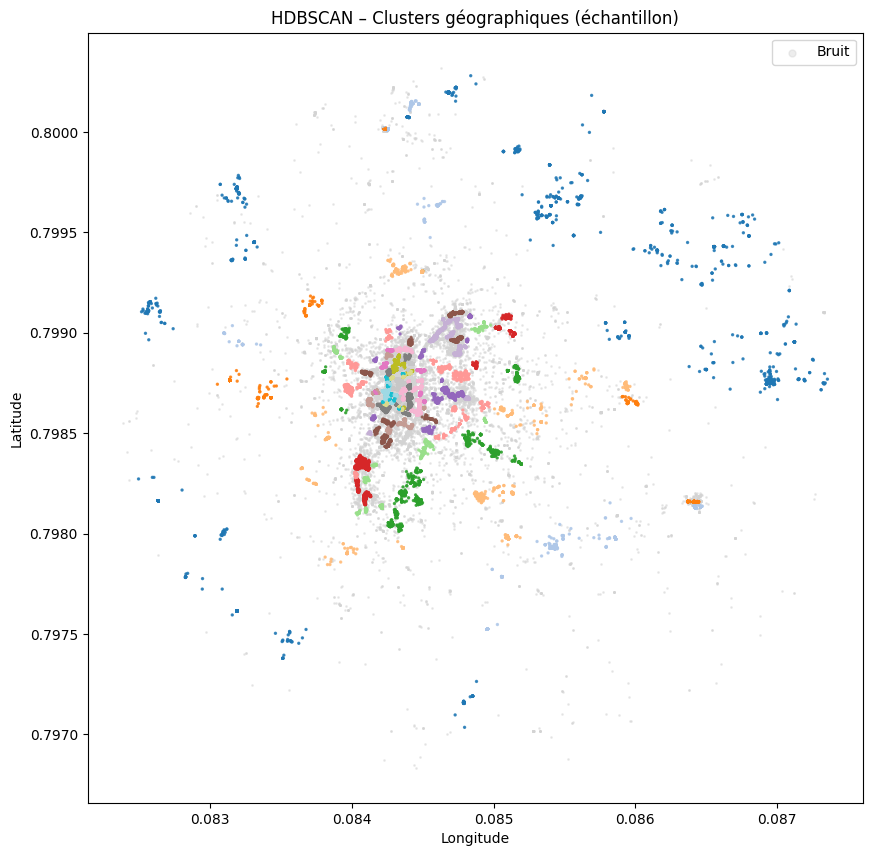

In [9]:
plt.figure(figsize=(10, 10))
# Prendre un échantillon pour la visualisation
sample_size = 50000
indices = np.random.choice(len(coords_rad), sample_size, replace=False)
coords_rad_sample = coords_rad.iloc[indices].values
labels_sample = labels[indices]

# Bruit
mask_noise = labels_sample == -1
plt.scatter(
    coords_rad_sample[mask_noise, 1],
    coords_rad_sample[mask_noise, 0],
    s=1,
    c='lightgrey',
    alpha=0.4,
    label='Bruit'
)

# Clusters
mask_cluster = labels_sample != -1
plt.scatter(
    coords_rad_sample[mask_cluster, 1],
    coords_rad_sample[mask_cluster, 0],
    s=2,
    c=labels_sample[mask_cluster],
    cmap='tab20',
    alpha=0.8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("HDBSCAN – Clusters géographiques (échantillon)")
plt.legend(markerscale=5)
plt.show()


## Afficher le résultat à la place Terraux/Hotel de Ville + Parc de la tête d'or

In [ ]:
# Créer une carte avec les clusters HDBSCAN

# Réinitialiser les indices pour éviter les problèmes
data2D_reset = data2D.reset_index(drop=True)
labels_reset = labels.copy()

# Créer la carte centrée sur Place des Terreaux
map_hdbscan = fl.Map(
    location=[45.76748, 4.833487],
    zoom_start=12
)

# Couleurs pour les clusters
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 
          'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'white', 'pink', 'gray']

# Ajouter les points avec les couleurs des clusters
for idx in range(len(data2D_reset)):
    cluster_id = labels_reset[idx]
    row = data2D_reset.iloc[idx]
    
    # Sauter le bruit (cluster -1)
    if cluster_id == -1:
        continue
    
    # Choisir la couleur selon le cluster
    color = colors[int(cluster_id) % len(colors)]
    
    # Ajouter un marqueur
    fl.CircleMarker(
        location=[row[' lat'], row[' long']],
        radius=3,
        popup=f'Cluster {cluster_id}',
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=1
    ).add_to(map_hdbscan)

# Ajouter les points de bruit en gris transparent
for idx in range(len(data2D_reset)):
    if labels_reset[idx] == -1:
        row = data2D_reset.iloc[idx]
        fl.CircleMarker(
            location=[row[' lat'], row[' long']],
            radius=1,
            popup='Bruit',
            color='gray',
            fill=True,
            fillColor='gray',
            fillOpacity=0.2,
            weight=0.5
        ).add_to(map_hdbscan)

# Ajouter les centres des clusters (POIs)
for cluster_id, poi_row in pois.iterrows():
    fl.Marker(
        location=[poi_row['lat_mean'], poi_row['lon_mean']],
        popup=f"Cluster {cluster_id}<br>{int(poi_row['nb_photos'])} photos",
        icon=fl.Icon(color=colors[int(cluster_id) % len(colors)], icon='info-sign')
    ).add_to(map_hdbscan)

# Sauvegarder la carte
map_hdbscan.save('map_hdbscan.html')
print("Carte HDBSCAN sauvegardée dans 'map_hdbscan.html'")
print(f"\nRésumé des clusters HDBSCAN dans Place des Terraux:")
print(pois)


In [16]:
# Carte pour Place des Terreaux et Parc de la Tête d'Or avec tous les points, y compris le bruit
map_small_area = fl.Map(location=[45.76748, 4.833487], zoom_start=14)
for idx in range(len(data2D_reset)):
    row = data2D_reset.iloc[idx]
    cluster_id = labels_reset[idx]
    color = 'gray' if cluster_id == -1 else colors[int(cluster_id) % len(colors)]
    fl.CircleMarker(
        location=[row[' lat'], row[' long']],
        radius=2 if cluster_id == -1 else 3,
        popup=f"Cluster {cluster_id}" if cluster_id != -1 else "Bruit",
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.5 if cluster_id == -1 else 0.8,
        weight=0.5 if cluster_id == -1 else 1
    ).add_to(map_small_area)
map_small_area.save('map_small_area.html')
print("Carte pour Place des Terreaux et Parc de la Tête d'Or sauvegardée dans 'map_small_area.html'")

# Carte pour tout Lyon sans le bruit, avec contours des clusters
from shapely.geometry import MultiPoint, Polygon
from shapely.ops import unary_union
from geopandas import GeoDataFrame
import geopandas as gpd
import matplotlib.pyplot as plt

# Créer un GeoDataFrame pour les clusters
filtered_df = df[df.cluster != -1]
gdf = gpd.GeoDataFrame(
    filtered_df,
    geometry=gpd.points_from_xy(filtered_df[' long'], filtered_df[' lat']),
    crs="EPSG:4326"
    )

# Calculer les contours convexes pour chaque cluster
convex_hulls = gdf.groupby('cluster').geometry.apply(lambda x: MultiPoint(list(x)).convex_hull)
hull_gdf = GeoDataFrame({"geometry": convex_hulls, "cluster": convex_hulls.index})

# Créer une carte pour tout Lyon sans le bruit
map_lyon_clusters = fl.Map(location=[45.75, 4.85], zoom_start=12)
for _, row in hull_gdf.iterrows():
    cluster_id = row['cluster']
    color = colors[int(cluster_id) % len(colors)]
    geo_json = fl.GeoJson(
        data=row['geometry'].__geo_interface__,
        style_function=lambda x, color=color: {
            'fillColor': color,
            'color': color,
            'weight': 2,
            'fillOpacity': 0.4
        }
    )
    geo_json.add_to(map_lyon_clusters)
map_lyon_clusters.save('map_lyon_clusters.html')
print("Carte pour tout Lyon sans le bruit sauvegardée dans 'map_lyon_clusters.html'")

Carte pour Place des Terreaux et Parc de la Tête d'Or sauvegardée dans 'map_small_area.html'
Carte pour tout Lyon sans le bruit sauvegardée dans 'map_lyon_clusters.html'
